# Actor-Critic Methods in Reinforcement Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement actor–critic algorithms
- Combine policy and value learning

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 3**.

---


## Lesson Brief

This lesson introduces the **actor-critic** idea: one part of the system chooses actions, and another estimates how good states or actions are.

Students will see why combining a policy learner with a value estimator can reduce variance and make learning more stable.

Why this matters: actor-critic methods are the foundation of many practical RL algorithms used in continuous control and modern AI systems.

This lesson is a bridge from basic policy gradients to stronger methods like PPO.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Machine Learning with Phil - "Everything You Need To Master Actor Critic Methods"**:
[Watch on YouTube](https://www.youtube.com/watch?v=LawaN3BdI00)

Why this pick:
- beginner-friendly structure.
- Explains the separate jobs of the actor and critic before showing implementation.
- Good support for students moving beyond pure value methods.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Actor: learns the policy and chooses actions.
- Critic: estimates value information to guide the actor.
- Advantage-like signal: tells whether an action was better than expected.
- Shared loop: both learn from the same experience.
- Variance reduction: one reason actor-critic can be more stable than pure policy gradients.

### Quick Check
- What does the actor learn?
- What does the critic learn?
- Why can this be more stable than pure policy gradients?
- Why is the critic useful even though it does not choose the action?

### Common Mistakes
- Swapping actor and critic roles.
- Thinking the critic chooses actions.
- Forgetting they optimize different objectives.
- Thinking actor-critic is a totally different idea instead of a policy-gradient method with extra value guidance.


## Actor-Critic in Plain Language

Actor-critic methods answer a practical problem in deep RL:

`Can we keep the flexibility of policy gradients while giving the policy better feedback than raw returns alone?`

### The actor

The actor is the part that decides:

`What action should I take?`

So it learns the policy.

### The critic

The critic is the part that estimates how good the current situation or action is.
It does not choose the action. It provides a learning signal.

### Why combine them?

Pure policy gradients can work, but they often have high variance.
The critic helps the actor learn with more informative feedback, which can make updates more stable and data-efficient.

### Memory rule

- actor -> acts
- critic -> critiques

That simple sentence often prevents the most common student confusion.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Install or import dependencies so later cells can run.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Pip progress lines and usually a confirmation that imports work.

**If you feel lost:** Fix any red install error before continuing—later cells assume this cell succeeded.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install "gymnasium[classic-control]" torch numpy matplotlib ipywidgets pillow -q
# Load a library so you can use its ready-made functions and types below.
import torch
# Load a library so you can use its ready-made functions and types below.
import torch.nn as nn
# Load a library so you can use its ready-made functions and types below.
import torch.optim as optim
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Show text or numbers in the cell output area under the code.
print('✅ Setup complete!')



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Part 1: Actor-Critic Architecture


### Step Guide

**What this cell does:** PyTorch-heavy block (network, loss, or training step)—read shapes and prints first.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `ActorCritic` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class ActorCritic(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, obs_dim, act_dim.
    def __init__(self, obs_dim=4, act_dim=2):
        # Execute: super().__init__()
        super().__init__()
        # Save a value in a name so the next lines can read it.
        self.shared = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(obs_dim, 128),
            # Call a PyTorch API (tensor/module/training-related).
            nn.ReLU(),
        # Close the parentheses opened earlier (end this function call / grouping).
        )
        # Save a value in a name so the next lines can read it.
        self.actor_head = nn.Linear(128, act_dim)
        # Another assignment—same idea: store a value for the lines below.
        self.critic_head = nn.Linear(128, 1)

    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x):
        # Save a value in a name so the next lines can read it.
        features = self.shared(x)
        # Create or update the greedy policy array (one int action id per state).
        policy_logits = self.actor_head(features)
        # Save a value in a name so the next lines can read it.
        state_value = self.critic_head(features)
        # Send a value back to whoever called this function.
        return policy_logits, state_value


## Part 2: Training Loop


### Step Guide

**What this cell does:** Define a helper you can read in one place before it is used later.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [3]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `train_actor_critic` (what it does): Minimal demonstration loop structure for actor-critic training.
def train_actor_critic(env_name='CartPole-v1', episodes=5):
    """Minimal demonstration loop structure for actor-critic training."""
    # Save a value in a name so the next lines can read it.
    env = gym.make(env_name)
    # Another assignment—same idea: store a value for the lines below.
    model = ActorCritic()
    # Another assignment—same idea: store a value for the lines below.
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Start a loop: repeat the indented block once per item in the sequence.
    for episode in range(episodes):
        # Save a value in a name so the next lines can read it.
        obs, _ = env.reset()
        # Another assignment—same idea: store a value for the lines below.
        total_reward = 0
        # Start a loop: repeat the indented block once per item in the sequence.
        for _ in range(200):
            # Save a value in a name so the next lines can read it.
            obs_t = torch.tensor(obs).float().unsqueeze(0)
            # Another assignment—same idea: store a value for the lines below.
            logits, value = model(obs_t)
            # Another assignment—same idea: store a value for the lines below.
            dist = torch.distributions.Categorical(logits=logits)
            # Another assignment—same idea: store a value for the lines below.
            action = dist.sample()
            # Another assignment—same idea: store a value for the lines below.
            next_obs, reward, done, trunc, _ = env.step(action.item())

            # Safely open/use a resource; Python cleans up when the block ends.
            with torch.no_grad():
                # Save a value in a name so the next lines can read it.
                _, next_value = model(torch.tensor(next_obs).float().unsqueeze(0))
            # Compute one Bellman backup candidate: reward + gamma * V(next_state).
            target = reward + 0.99 * next_value.item() * (0 if (done or trunc) else 1)
            # Save a value in a name so the next lines can read it.
            advantage = target - value.item()

            # Another assignment—same idea: store a value for the lines below.
            actor_loss = -dist.log_prob(action) * advantage
            # Another assignment—same idea: store a value for the lines below.
            critic_loss = (value.squeeze() - target) ** 2
            # Another assignment—same idea: store a value for the lines below.
            loss = actor_loss + critic_loss

            # Execute: optimizer.zero_grad()
            optimizer.zero_grad()
            # Execute: loss.backward()
            loss.backward()
            # Execute: optimizer.step()
            optimizer.step()

            # Save a value in a name so the next lines can read it.
            obs = next_obs
            # Another assignment—same idea: store a value for the lines below.
            total_reward += reward
            # If the condition is True, run the indented block under this line.
            if done or trunc:
                # Stop the loop completely and continue after the loop block.
                break
        # Show text or numbers in the cell output area under the code.
        print(f"Episode {episode + 1}: reward={total_reward}")

    # Execute: env.close()
    env.close()
    # Send a value back to whoever called this function.
    return model


# Save a value in a name so the next lines can read it.
_ = train_actor_critic(episodes=3)


Episode 1: reward=14.0
Episode 2: reward=20.0
Episode 3: reward=19.0


## CartPole step-through (GIF + slider)

Same **Gymnasium** loop as Unit 1, shown as **pixels**. Policy is **random** here for a stable demo; after you understand how your actor picks actions, try wiring this block to a greedy policy from `model` as an extension.


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


10 frames | return=9.0 | term=True | trunc=False


objc[77272]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11a504138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11aa889c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77272]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11a504188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11aa88a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77272]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11a503c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11aa88a68). T

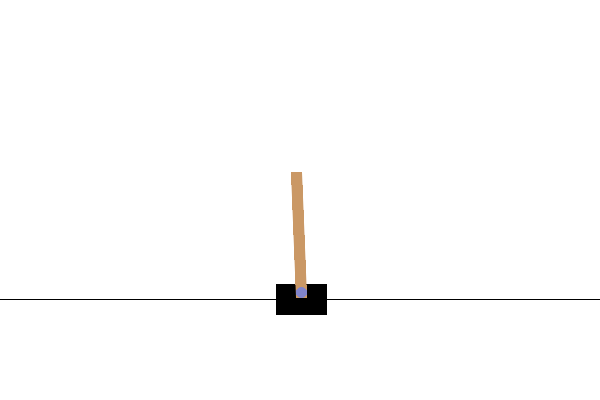

In [4]:
%pip install ipywidgets pillow -q

import pathlib
import sys

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError("Could not find course09_step_viz.py — run from inside Course 09.")

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz

env_vis = gym.make("CartPole-v1", render_mode="rgb_array")


def random_policy(obs, step):
    return int(env_vis.action_space.sample())


frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
    env_vis, random_policy, max_steps=100, seed=0
)
env_vis.close()

print(f"{len(frames)} frames | return={total_r:.1f} | term={term} | trunc={trunc}")
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="CartPole-v1 timestep")

## Real-World Applications

- **Robotics**: Continuous control (robot arm, walking)
- **Autonomous Vehicles**: Steering, acceleration control
- **Game AI**: Real-time strategy games
- **Finance**: Portfolio optimization

---

**End of Notebook**

## 🌍 Contrast Example — REINFORCE on CartPole

**Industry context:**
- Actor-critic methods belong to the same broad policy-optimization family as simpler policy-gradient methods
- Robotics and control systems often move from simple policy gradients toward actor-critic and PPO-style methods
- This example is included as a contrast, not as a claim that REINFORCE equals actor-critic

We implement **REINFORCE** on CartPole-v1 so students can contrast it with the actor-critic structure introduced earlier in the notebook.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Episode   0 | Avg reward: 13.0


Episode  50 | Avg reward: 27.7


Episode 100 | Avg reward: 35.8


Episode 150 | Avg reward: 94.6


Episode 200 | Avg reward: 273.1


Episode 250 | Avg reward: 148.3


Episode 300 | Avg reward: 177.7


Episode 350 | Avg reward: 129.8


Episode 400 | Avg reward: 110.2


Episode 450 | Avg reward: 386.7


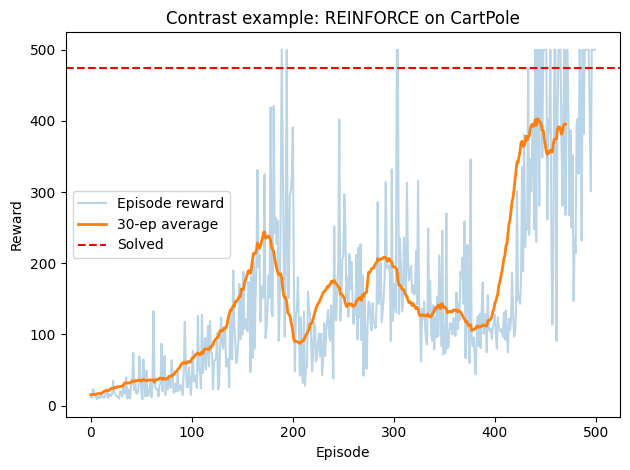

In [5]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import torch, torch.nn as nn, torch.optim as optim
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import numpy as np, matplotlib.pyplot as plt

# Call a PyTorch API (tensor/module/training-related).
torch.manual_seed(42)
# Save a value in a name so the next lines can read it.
env = gym.make('CartPole-v1')

# Class `PolicyNet` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class PolicyNet(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def __init__(self):
        # Execute: super().__init__()
        super().__init__()
        # Save a value in a name so the next lines can read it.
        self.net = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(4, 128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128, 2), nn.Softmax(dim=-1)
        # Close the parentheses opened earlier (end this function call / grouping).
        )
    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x): return self.net(x)

# Create or update the greedy policy array (one int action id per state).
policy  = PolicyNet()
# Save a value in a name so the next lines can read it.
opt     = optim.Adam(policy.parameters(), lr=2e-3)
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA   = 0.99; ep_rewards = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(500):
    # Save a value in a name so the next lines can read it.
    obs,_ = env.reset(); log_probs=[]; rewards_ep=[]
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(500):
        # Save a value in a name so the next lines can read it.
        probs  = policy(torch.tensor(obs).float().unsqueeze(0))
        # Another assignment—same idea: store a value for the lines below.
        dist   = torch.distributions.Categorical(probs)
        # Another assignment—same idea: store a value for the lines below.
        action = dist.sample()
        # Add one new item to the end of a list (the list grows in place).
        log_probs.append(dist.log_prob(action))
        # Save a value in a name so the next lines can read it.
        obs, r, done, trunc, _ = env.step(action.item())
        # Add one new item to the end of a list (the list grows in place).
        rewards_ep.append(r)
        # If the condition is True, run the indented block under this line.
        if done or trunc: break

    # ── Compute discounted returns ──────────────────────────────────────────
    # Save a value in a name so the next lines can read it.
    G = 0; returns = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in reversed(rewards_ep):
        # Save a value in a name so the next lines can read it.
        G = r + GAMMA*G; returns.insert(0, G)
    # Another assignment—same idea: store a value for the lines below.
    returns = torch.tensor(returns).float()
    # Another assignment—same idea: store a value for the lines below.
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ── Policy gradient loss ────────────────────────────────────────────────
    # Save a value in a name so the next lines can read it.
    loss = -torch.stack([lp*R for lp,R in zip(log_probs, returns)]).sum()
    # Execute: opt.zero_grad(); loss.backward(); opt.step()
    opt.zero_grad(); loss.backward(); opt.step()
    # Add one new item to the end of a list (the list grows in place).
    ep_rewards.append(sum(rewards_ep))
    # If the condition is True, run the indented block under this line.
    if episode%50==0: print(f"Episode {episode:3d} | Avg reward: {np.mean(ep_rewards[-20:]):.1f}")

# Execute: env.close()
env.close()
# Save a value in a name so the next lines can read it.
ma = np.convolve(ep_rewards, np.ones(30)/30, 'valid')
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(ep_rewards, alpha=0.3, label="Episode reward")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(ma, lw=2, label="30-ep average")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(475, color='red', linestyle='--', label="Solved")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Contrast example: REINFORCE on CartPole")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.legend(); plt.tight_layout(); plt.show()


In [6]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Papers
- Williams (1992) — [REINFORCE](https://link.springer.com/article/10.1007/BF00992696)
- Schulman et al. (2017) — [PPO: Proximal Policy Optimization](https://arxiv.org/abs/1707.06347)
- Mnih et al. (2016) — [A3C: Asynchronous Methods for Deep RL](https://arxiv.org/abs/1602.01783)

### State-of-the-art
- OpenAI's ChatGPT uses RLHF (PPO) to align responses with human preferences
- Boston Dynamics robots use PPO for locomotion control
"""))


## 📚 References & Further Reading

### Papers
- Williams (1992) — [REINFORCE](https://link.springer.com/article/10.1007/BF00992696)
- Schulman et al. (2017) — [PPO: Proximal Policy Optimization](https://arxiv.org/abs/1707.06347)
- Mnih et al. (2016) — [A3C: Asynchronous Methods for Deep RL](https://arxiv.org/abs/1602.01783)

### State-of-the-art
- OpenAI's ChatGPT uses RLHF (PPO) to align responses with human preferences
- Boston Dynamics robots use PPO for locomotion control


## 📝 Summary

You learned that **Actor-Critic** combines a policy learner with a value estimator so the policy update has better guidance and typically lower variance than plain REINFORCE. **PPO** can be understood as a later practical refinement built on this broader family of policy-optimization ideas.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


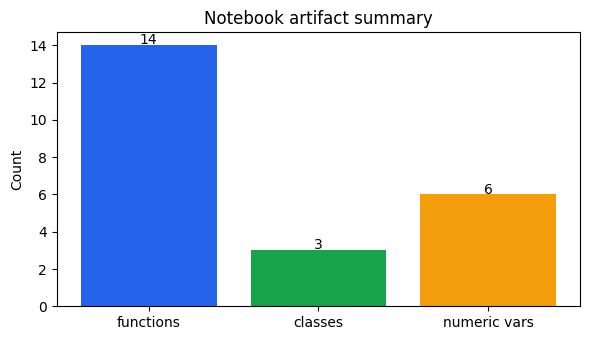

In [7]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Actor-critic methods combine a policy learner with a value-based guide so each part supports the other during training.

**If students remember one idea:** The actor decides what to do, while the critic evaluates how good the decision appears to be.

**Quick check before moving on:**
- Can you explain the separate jobs of the actor and the critic?
- Can you describe why the critic can reduce variance in policy learning?

**Bridge to the next step:** This prepares students for PPO, which adds practical constraints that make policy optimization more stable.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
